<a href="https://colab.research.google.com/github/micahsmithh/ece1395-pitching-classification/blob/main/pitching_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aidan Uher and Micah Smith: ECE 1395 Final Project

This project will be focused on using data from Major League Baseball pitcher's pitches and using machine learning to build a model that can predict pitch type.

## Data Loading

The data used is from Baseball Savant, a website that compiles an extensive amount of data from the MLB for teams, pitchers, batters, etc. The data being used is stored in csv format and can be found in the project GitHub.

In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.io
from scipy.optimize import minimize
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [29]:

file_path = 'https://raw.githubusercontent.com/micahsmithh/ece1395-pitching-classification/main/input/pitch_movement_2025.csv'

In [30]:
pitch_data = pd.read_csv(file_path)

In [31]:
pitch_data.head()

,year,"last_name, first_name",pitcher_id,team_name,team_name_abbrev,pitch_hand,avg_speed,pitches_thrown,total_pitches,pitches_per_game,...,league_break_z,diff_z,rise,pitcher_break_z_induced,pitcher_break_x,league_break_x,diff_x,tail,percent_rank_diff_z,percent_rank_diff_x
0,2025,"Peralta, Freddy",642547,Brewers,MIL,R,94.8,1651,3086,19.049383,...,-15.1,1.2,8.0,16.8,4.6,-8.3,-3.7,-45.0,0.791762,0.098398
1,2025,"Gausman, Kevin",592332,Blue Jays,TOR,R,94.5,1627,3030,18.703704,...,-14.6,0.5,3.0,16.8,11.1,-7.4,3.7,50.0,0.622426,0.899314
2,2025,"Ray, Robbie",592662,Giants,SF,L,93.6,1593,3069,18.944444,...,-14.8,1.5,10.0,18.2,8.2,-6.9,1.3,19.0,0.848970,0.649886
3,2025,"Nelson, Ryne",669194,D-backs,AZ,R,95.7,1526,2466,15.222222,...,-13.3,2.5,19.0,19.2,3.2,-6.7,-3.4,-52.0,0.956522,0.121281
4,2025,"Parker, Mitchell",680730,Nationals,WSH,L,93.0,1501,2705,16.697531,...,-14.4,0.6,4.0,18.0,5.8,-6.3,-0.5,-9.0,0.645309,0.414188


In [38]:
#Pitch proportions
print(pitch_data['pitch_type'].value_counts(normalize=True) * 100)


pitch_type
FF    21.965898
SL    15.596790
SI    15.446339
CH    13.390171
CU    11.334002
FC     9.227683
ST     8.876630
FS     4.162487
Name: proportion, dtype: float64


In [39]:
pitch_data = pitch_data[~pitch_data['pitch_type'].isin(['SV', 'FO'])]
print(pitch_data['pitch_type'].value_counts(normalize=True) * 100)

pitch_type
FF    21.965898
SL    15.596790
SI    15.446339
CH    13.390171
CU    11.334002
FC     9.227683
ST     8.876630
FS     4.162487
Name: proportion, dtype: float64


In [40]:
print(pitch_data['pitch_type_name'].value_counts(normalize=True) * 100)

pitch_type_name
4-Seam Fastball    21.965898
Slider             15.596790
Sinker             15.446339
Changeup           13.390171
Curveball          11.334002
Cutter              9.227683
Sweeper             8.876630
Split-Finger        4.162487
Name: proportion, dtype: float64


In [41]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
pitch_data['pitch_hand'] = le.fit_transform(pitch_data['pitch_hand'])

In [42]:
#Define feature space
features = ['avg_speed', 'pitcher_break_z_induced', 'pitcher_break_x', 'pitch_hand'
]

#Features and labels
X = pitch_data[features]
y = pitch_data['pitch_type']

#Verify
print(X.shape)
print(y.shape)

(1994, 4)
(1994,)


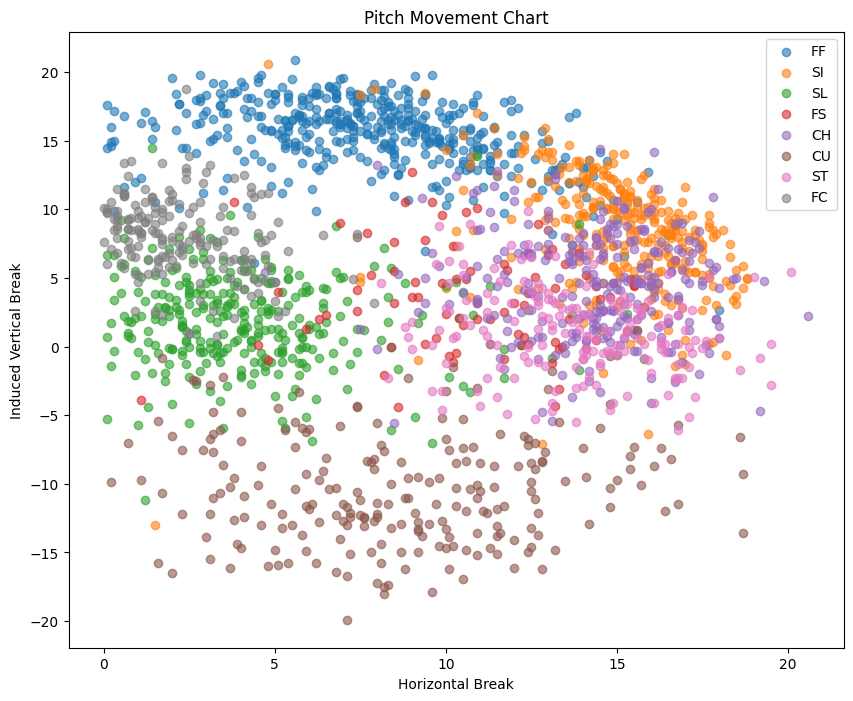

In [43]:
fig, ax = plt.subplots(figsize=(10, 8))

for pitch in pitch_data['pitch_type'].unique():
    subset = pitch_data[pitch_data['pitch_type'] == pitch]
    ax.scatter(subset['pitcher_break_x'], subset['pitcher_break_z_induced'], label=pitch, alpha=0.6)

ax.set_xlabel('Horizontal Break')
ax.set_ylabel('Induced Vertical Break')
ax.set_title('Pitch Movement Chart')
ax.legend()
plt.show()

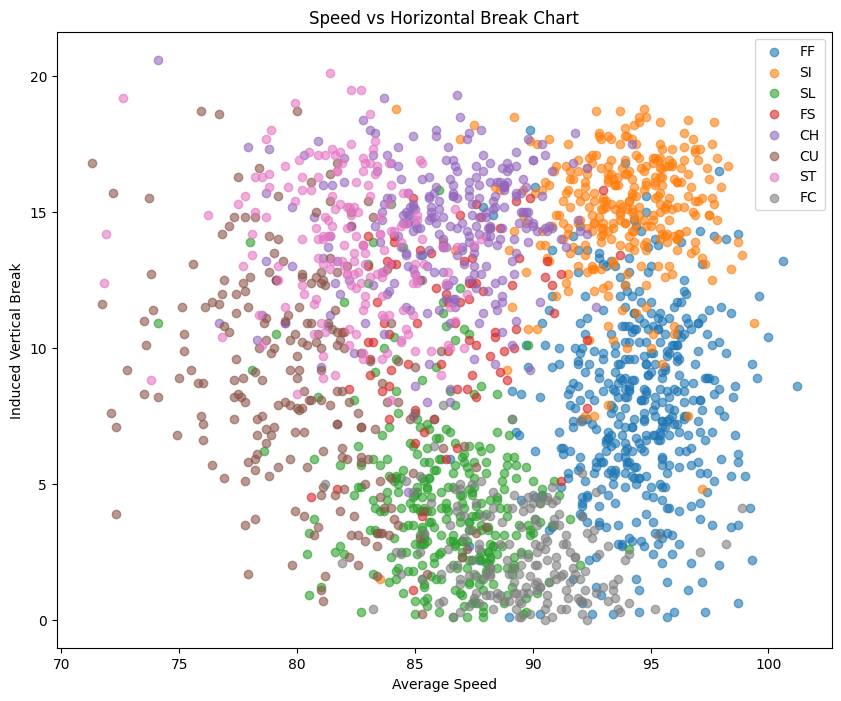

In [52]:
fig, ax = plt.subplots(figsize=(10, 8))

for pitch in pitch_data['pitch_type'].unique():
    subset = pitch_data[pitch_data['pitch_type'] == pitch]
    ax.scatter(subset['avg_speed'], subset['pitcher_break_x'], label=pitch, alpha=0.6)

ax.set_xlabel('Average Speed')
ax.set_ylabel('Induced Vertical Break')
ax.set_title('Speed vs Horizontal Break Chart')
ax.legend()
plt.show()

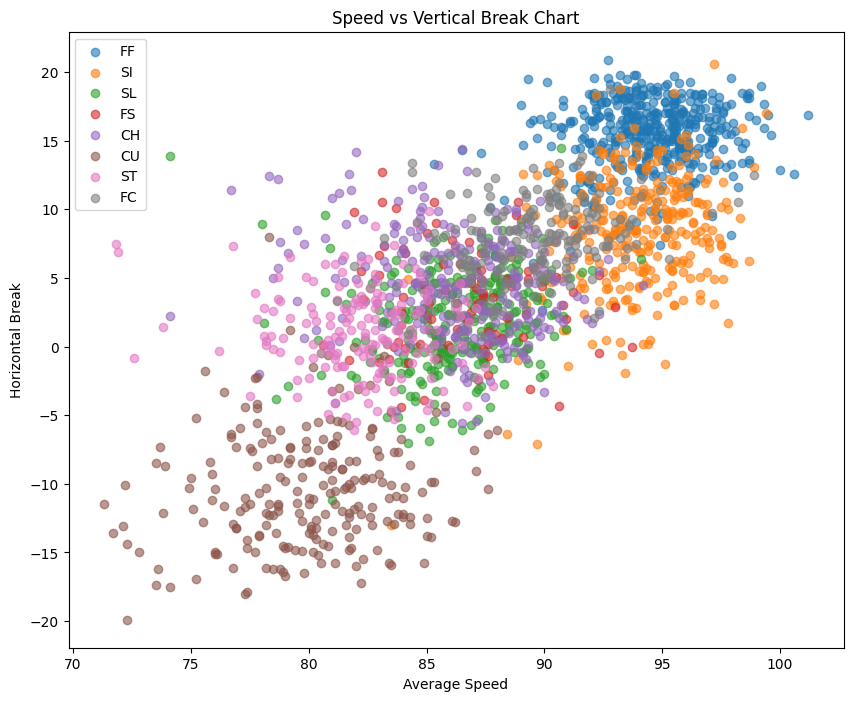

In [53]:
fig, ax = plt.subplots(figsize=(10, 8))

for pitch in pitch_data['pitch_type'].unique():
    subset = pitch_data[pitch_data['pitch_type'] == pitch]
    ax.scatter(subset['avg_speed'], subset['pitcher_break_z_induced'], label=pitch, alpha=0.6)

ax.set_xlabel('Average Speed')
ax.set_ylabel('Horizontal Break')
ax.set_title('Speed vs Vertical Break Chart')
ax.legend()
plt.show()

In [45]:
def sigmoid(z):
    """
    Compute the sigmoid of z.

    Parameters:
    z : array_like
        Input value(s), can be scalar, vector, or matrix

    Returns:
    g : array_like
        Sigmoid of z, same shape as input
    """
    # TODO: Implement sigmoid function
    g =  1 / (1 + np.exp(-z))  # TODO
    return g

In [46]:
def costFunction(theta, X, y):
    """
    Compute the cost for logistic regression.

    Parameters:
    theta : array_like
        Parameters of shape (n+1,)
    X : array_like
        Feature matrix of shape (m, n+1) with bias column
    y : array_like
        Labels of shape (m,)

    Returns:
    J : float
        The cost
    """
    m = len(y)

    # TODO: Compute hypothesis h = sigmoid(X @ theta)
    h = sigmoid(X @ theta)  # TODO

    # Added clipping because of warning in toy dataset that log(0) occurred
    h = np.clip(h, 1e-15, 1-1e-15)

    # TODO: Compute cost using the formula
    # J = -(1/m) * sum(y*log(h) + (1-y)*log(1-h))
    # Hint: Use np.log() and be careful with element-wise operations
    J = -(1/m) * np.sum(y*np.log(h) + (1-y)*np.log(1-h))  # TODO

    return J


def gradFunction(theta, X, y):
    """
    Compute the gradient for logistic regression.

    Parameters:
    theta : array_like
        Parameters of shape (n+1,)
    X : array_like
        Feature matrix of shape (m, n+1) with bias column
    y : array_like
        Labels of shape (m,)

    Returns:
    grad : array_like
        Gradient of shape (n+1,)
    """
    m = len(y)

    # TODO: Compute hypothesis
    h = sigmoid(X @ theta)  # TODO

    # TODO: Compute gradient

    grad = 1/m *(X.T @ (h-y))   # TODO

    return grad

In [47]:
def trainOneVsAll(X_train, y_train, random_state=0):
    """
    Train multiple binary logistic regression classifiers using one-vs-all approach.

    Parameters:
    X_train : array_like
        Training features of shape (m, n+1) with bias column
    y_train : array_like
        Training labels of shape (m,)
    random_state : int
        Random seed for reproducibility

    Returns:
    models : list
        List of trained LogisticRegression models
    classes : array_like
        Array of unique class labels
    """
    # Find unique classes
    classes = np.unique(y_train)
    num_classes = len(classes)

    # Initialize list for models
    models = []

    # Train one classifier per class
    for c in range(num_classes):
        current_class = classes[c]

        # TODO: Create binary labels (1 if y_train == current_class, else 0)
        y_binary = (y_train == current_class).astype(int)  # TODO

        # TODO: Train logistic regression model
        mdl = LogisticRegression(random_state=random_state, max_iter=1000).fit(X_train, y_binary)  # TODO: LogisticRegression(random_state=random_state, max_iter=1000).fit(X_train, y_binary)

        models.append(mdl)
        print(f"Trained classifier for class {current_class}")

    return models, classes

In [48]:
def predictOneVsAll(models, classes, X_test):
    """
    Predict class labels using trained one-vs-all classifiers.

    Parameters:
    models : list
        List of trained LogisticRegression models
    classes : array_like
        Array of unique class labels
    X_test : array_like
        Test features of shape (d, n+1)

    Returns:
    y_pred : array_like
        Predicted class labels of shape (d,)
    probas : array_like
        Probability matrix of shape (d, num_classes)
    """
    num_classes = len(models)
    num_samples = X_test.shape[0]

    # Initialize probability matrix
    probas = np.zeros((num_samples, num_classes))

    # Get probabilities from each classifier
    for c in range(num_classes):
        # TODO: Get probability of positive class from classifier c
        # Hint: models[c].predict_proba(X_test) returns probabilities for class 0 and class 1
        # You want the probability of class 1 (positive class), which is column index 1
        proba = models[c].predict_proba(X_test)
        probas[:, c] = proba[:, 1]  # TODO: Which column of proba?

    # TODO: Find class with highest probability for each sample
    # Hint: Use np.argmax()
    class_indices = np.argmax(probas, axis=1)  # TODO: Axis is 1 because we need to find maximum in each row

    # TODO: Convert indices to actual class labels
    y_pred = classes[class_indices]  # TODO: classes[class_indices]

    return y_pred, probas

In [69]:
# Convert pitch_hand to binary: R=1, L=0
pitch_data['pitch_hand_bin'] = pitch_data['pitch_hand'].astype(str).apply(lambda x: 1 if x.upper() == 'R' else 0)

# Features
X = pitch_data[['pitch_hand_bin', 'avg_speed', 'pitcher_break_z_induced', 'pitcher_break_x']].values

# Target
y = pitch_data['pitch_type'].values

print("Feature matrix X shape:", X.shape)
print("Target vector y shape:", y.shape)

Feature matrix X shape: (1994, 4)
Target vector y shape: (1994,)


In [84]:
D = 39
np.random.seed(D)
m = X.shape[0]


indices = np.random.permutation(m)
split = int(0.9 * m)

# Indices for train/test
train_idx = indices[:split]
test_idx = indices[split:]

# Split data
X_train = X[train_idx]
y_train = y[train_idx]
X_test = X[test_idx]
y_test = y[test_idx]

In [85]:
# TODO: Train one-vs-all classifier
models, classes = trainOneVsAll(X_train, y_train, random_state=D)

# TODO: Make predictions on training data
y_pred_train, _ = predictOneVsAll(models, classes, X_train)

# TODO: Make predictions on testing data
y_pred_test, _ = predictOneVsAll(models, classes, X_test)

# TODO: Compute accuracies
train_accuracy = np.sum(y_pred_train == y_train) / len(y_pred_train) * 100  # TODO
test_accuracy = np.sum(y_pred_test == y_test) / len(y_pred_test) * 100   # TODO

print(f"\nResults:")
print(f"Number of classes: {len(classes)}")
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")
print(f"Training accuracy: {train_accuracy:.2f}%")
print(f"Testing accuracy: {test_accuracy:.2f}%")

Trained classifier for class CH
Trained classifier for class CU
Trained classifier for class FC
Trained classifier for class FF
Trained classifier for class FS
Trained classifier for class SI
Trained classifier for class SL
Trained classifier for class ST

Results:
Number of classes: 8
Training samples: 1794
Testing samples: 200
Training accuracy: 72.35%
Testing accuracy: 74.50%


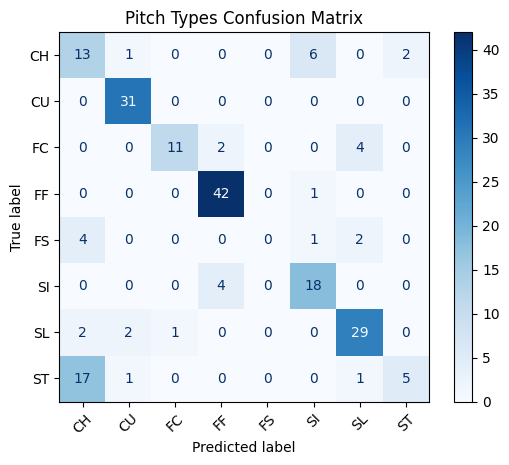

In [86]:
# Encode labels to integers
le = LabelEncoder()


# Encode labels Predictions
y_test_enc = le.fit_transform(y_test)
y_pred_enc = le.transform(y_pred_test)

# Compute confusion matrix
cm = confusion_matrix(y_test_enc, y_pred_enc)

# Display with pitch names
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Pitch Types Confusion Matrix")
plt.show()